In [1]:
import warnings
import numpy as np
import scipy as sp
%matplotlib inline
import matplotlib.pyplot as plt
import tanglepack
import tanglepack.InitialManifold
%load_ext autoreload
%autoreload 2

/mnt/c/Users/etccu/Documents/TanglePack/env/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [166]:
def henon(point):
    """defines the henon map for classical parameters to test basic functionality"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([y - k + x ** 2, -b * x])


def henon_inverse(point):
    """defines the inverse henon map for classical parameters"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([-y / b, x + k - (y ** 2) / (b ** 2)])


def henon_jacobian(point):
    """defines the jacobian for the henon map"""

    k, b = (10, 1)

    x = point[0]
    y = point[1]

    return np.array([[2*x, 1], [-b, 0]])
    

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
entered eigenvalues
eigen [ 0.99317577 -0.11662714]
first point: [ 4.3277326  -4.31792758]
eigen [ 0.99317577 -0.11662714]
first pre_iterate: [ 4.31792758 -4.31676597]
[ 0.99317577 -0.11662714]


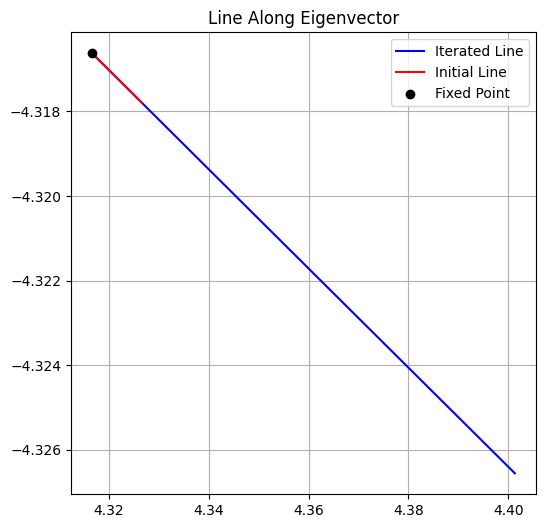

In [3]:
# guess = np.array([0.6, 0.2])
guess = np.array([4, -4])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

manifold = tanglepack.InitialManifold.InitialManifold(point)

eigenvector = point.eigenvectors[0][0]
print(eigenvector)

t_values = np.linspace(0, 1e-2, 100)

line = np.array([point.fixed_point[0] + t * eigenvector for t in t_values])

X, Y = line[:, 0], line[:, 1]

# iterated_line = np.array(henon(line))
iterated_line = np.array(list(map(henon, line)))

X, Y = iterated_line[:, 0], iterated_line[:, 1]

# Plot
plt.figure(figsize=(6,6))
plt.plot(X, Y, 'b-', label="Iterated Line")  # Line

X, Y = line[:, 0], line[:, 1]
plt.plot(X, Y, 'r-', label="Initial Line")  # Line

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='black', zorder=3, label="Fixed Point")  # Mark the start point
# plt.axhline(0, color='black', linewidth=0.5)
# plt.axvline(0, color='black', linewidth=0.5)
plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()

Okay so that is a manually iterated line based on the jacobian eigenvectors. Now we will check out the built in iteration

This is the fixed point [[ 4.31662458 -4.31662318]]
difference: [[1.47438772e-09 1.39904294e-06]]
updated difference: 0.011184341740278863
entered eigenvalues
entered eigenvalues
eigen [ 0.99317577 -0.11662714]
first point: [ 4.3277326  -4.31792758]
eigen [ 0.99317577 -0.11662714]
first pre_iterate: [ 4.31792758 -4.31676597]
[array([ 4.31662458, -4.31662318]), array([ 4.31792758, -4.31676597]), array([ 4.3277326 , -4.31792758])]
number of points: 5
---------
inner trigger: 0
inner trigger: 1
inner trigger: 2
points: [array([ 4.31662458, -4.31662318]), array([ 4.31792758, -4.31676597]), array([ 4.3277326 , -4.31792758]), array([ 4.3277326 , -4.31792758]), array([ 4.41134185, -4.3277326 ])]


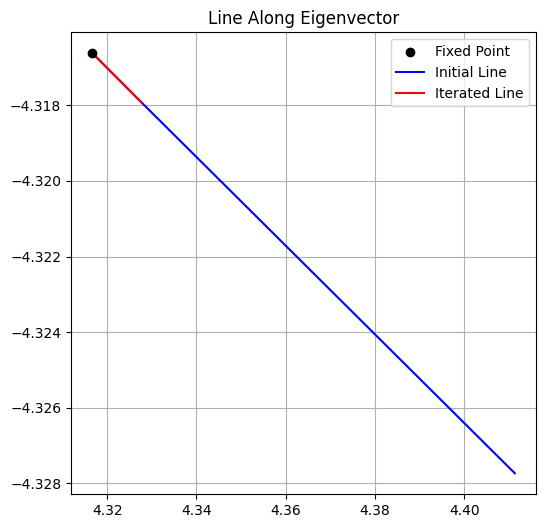

In [6]:
guess = np.array([4, -4])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

manifold = tanglepack.InitialManifold.InitialManifold(point)

print(manifold.points.points)

points1 = np.array(manifold.points.points)

manifold.iterate_manifold()

print(f"points: {manifold.points.points}")

points2 = np.array(manifold.points.points)

plt.figure(figsize=(6,6))

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='black', zorder=3, label="Fixed Point")  # Mark the start point

plt.plot(points2[:, 0], points2[:, 1], 'b-', label="Initial Line")

plt.plot(points1[:, 0], points1[:, 1], 'r-', label="Iterated Line")

plt.grid()
plt.legend()
plt.title("Line Along Eigenvector")
plt.show()

Perfect! We have now got the first fundamental segment and its first iterate with built in methods
Next we want to work on the refinement

In [269]:
guess = np.array([5, 0])

point = tanglepack.FixedPoint(henon, guess, dynamical_map_inverse=henon_inverse, jacobian_function=henon_jacobian)

print('bob')

manifold = tanglepack.InitialManifold.InitialManifold(point)

print('bob2')

# print(manifold.points.points)

points1 = np.array(manifold.points.points)

manifold.iterate_manifold()
manifold.iterate_manifold()

# print(f"points: {manifold.points.points}")

points2 = np.array(manifold.points.points)

manifold.iterate_manifold()
# manifold.iterate_manifold()

for i in range(4):
    manifold.iterate_manifold()

points3 = np.array(manifold.points.points)

This is the fixed point [[ 4.31662478 -4.31662478]]
Fixed Point Accurarcy: 0.0033886167370906404
entered eigenvalues
bob
eigen [-0.99317577  0.11662713]
eigen [-0.99317577  0.11662713]
---------
number of points: 3
0 passes
bob2
---------
number of points: 6
0 passes
---------
number of points: 12
0 passes
---------
number of points: 24
0 passes
---------
number of points: 48
0 passes
---------
number of points: 50
1 passes
---------
number of points: 54
2 passes
---------
number of points: 56
3 passes
---------
number of points: 58
4 passes
---------
number of points: 116
0 passes
---------
number of points: 150
1 passes
---------
number of points: 176
2 passes
---------
number of points: 194
3 passes
---------
number of points: 208
4 passes
---------
number of points: 216
5 passes
---------
number of points: 222
6 passes
---------
number of points: 226
7 passes
---------
number of points: 230
8 passes
---------
number of points: 232
9 passes
---------
number of points: 234
10 passes


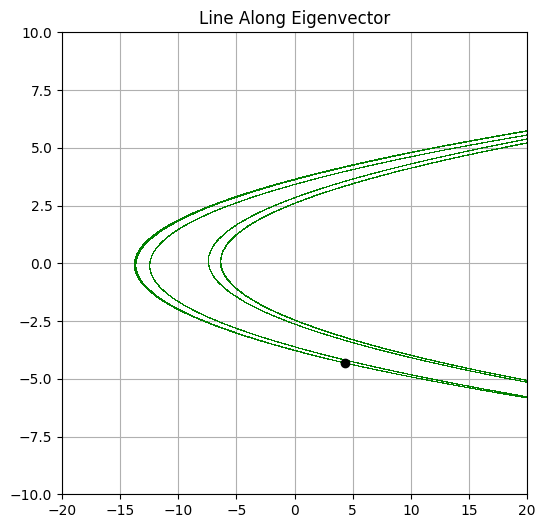

In [273]:
plt.figure(figsize=(6,6))

plt.scatter(point.fixed_point[0][0], point.fixed_point[0][1], color='black', zorder=3, label="Fixed Point")  # Mark the start point

plt.plot(points3[:, 0], points3[:, 1], c='g', label="2nd Iterate", linewidth=.1,antialiased=False)

# plt.scatter(points3[:, 0], points3[:, 1], c='k', label="2nd Iterate", s=3)

plt.plot(points2[:, 0], points2[:, 1], c='g', label="1st Iterate")

plt.plot(points1[:, 0], points1[:, 1], 'r-', label="Initial Segment")

plt.grid()
# plt.legend()
plt.title("Line Along Eigenvector")

plt.xlim([-20, 20])
plt.ylim([-10, 10])

# plt.xlim([4, 5])
# plt.ylim([-5, -2.5])

plt.show()

In [45]:
print(f"points: {len(manifold.points.points)}")

points: 195591


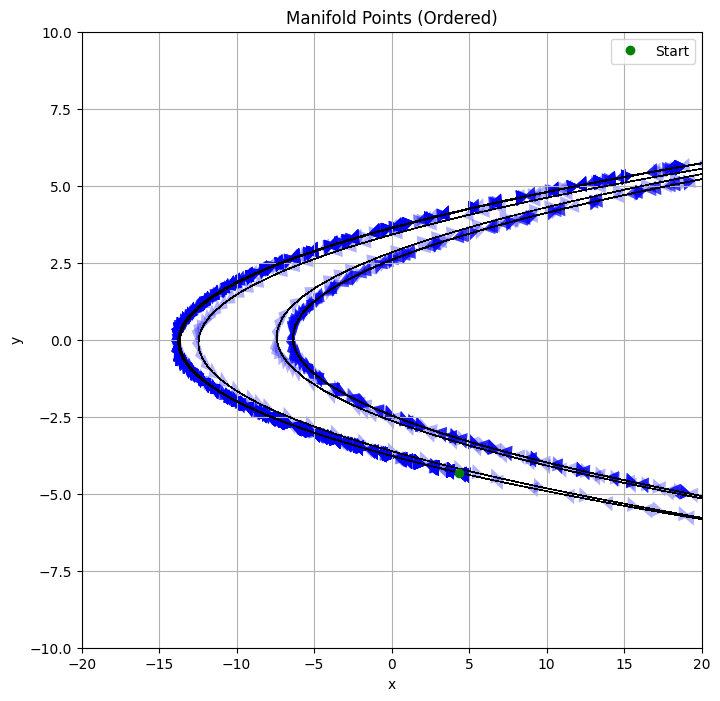

In [272]:
import matplotlib.pyplot as plt
import numpy as np

points_array = points3 # Replace with your actual points list

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the manifold connecting each point in the order they're stored
ax.plot(points_array[:, 0], points_array[:, 1], '-o', markersize=0, linewidth=0.5, color='k', antialiased=False)

# Highlight the first point
ax.plot(points_array[0, 0], points_array[0, 1], 'go', label='Start')

# Add arrows to show direction
for i in range(len(points_array) - 1):
    ax.arrow(points_array[i, 0], points_array[i, 1],
             points_array[i + 1, 0] - points_array[i, 0],
             points_array[i + 1, 1] - points_array[i, 1],
             shape='full', lw=0, length_includes_head=True, head_width=0.5, color='blue', alpha=0.3)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Manifold Points (Ordered)')
ax.legend()
ax.grid(True)

# set limits if your manifold blows up
plt.xlim([-20, 20])
plt.ylim([-10, 10])


# plt.xlim([4, 4.4])
# plt.ylim([-5, -2.5])


plt.show()


In [259]:
print((manifold.fixed_point.fixed_point[0][0] - manifold.fixed_point.fixed_point[0][1])/np.sqrt(2))

6.1046293133874
